
# WSX solenoid — G4BL vs OPALX

The same 13 particles go through the same field map in both codes; this compares the
two outputs particle by particle.

**Frame:** `z` in `wsx_solenoid.g4bl` [mm] / 1000 == path length `s` in
`wsx_solenoid.in` [m], exactly. Field spans 300–3300 mm, recording planes at 150 and
3450 mm, both in field-free drift.

Order of use:
1. Run **Setup** and **Write the particle files** below.
2. Run both codes (commands in the cell after that).
3. Run everything from **Readers** down.


## Setup


In [65]:
import subprocess, sys
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

from opalxruns.opalx_diagnostics import parse_opal_stat

HERE = Path.cwd()

# --- physics constants -------------------------------------------------------
MU_MASS   = 0.1056583755          # GeV
MU_MASS_MEV = MU_MASS * 1e3       # mass in MeV/c^2; numerically also m*c in
                                  #   MeV/c, which converts beta*gamma <-> MeV/c
P0        = 0.028                 # GeV/c   (g4bl referenceMomentum=28)
BG0       = P0 / MU_MASS          # beta*gamma
GAMMA0    = np.sqrt(1.0 + BG0**2)
BETA0     = BG0 / GAMMA0
# Both divisors below are the speed of light, in two unit scalings.
# Brho = p/q [T*m]; the 0.299792458 is 1e-9*c, which is what makes GeV/c work.
# It assumes charge = 1 elementary charge (true for the mu+ here).
BRHO      = P0 / 0.299792458      # T*m
C_MM_PER_NS = 299.792458          # c in mm/ns -- g4bl reports mm and ns

# --- geometry ----------------------------------------------------------------
Z_IN_MM, Z_OUT_MM = 150.0, 3450.0          # recording planes, both codes

# --- step sizes for the test set ---------------------------------------------
# x, y, z [m];  x' = px/pz and y' = py/pz [rad, i.e. trajectory angles, not
# momenta];  d = dp/p [dimensionless].
EPS = dict(x=1e-3, xp=1e-3, y=1e-3, yp=1e-3, z=1e-3, d=1e-3)

# index pairs (plus, minus) for the finite-difference transfer map, in the
# canonical coordinate order (x, x', y, y', zeta, delta)
PAIRS  = [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12)]
LABELS = ["x", "x'", "y", "y'", "zeta", "delta"]

print(f"beta*gamma = {BG0:.7f}   beta = {BETA0:.7f}   gamma = {GAMMA0:.7f}")
print(f"beta*c     = {BETA0 * C_MM_PER_NS:.4f} mm/ns")
print(f"Brho       = {BRHO:.6f} T*m")


beta*gamma = 0.2650050   beta = 0.2561628   gamma = 1.0345181
beta*c     = 76.7957 mm/ns
Brho       = 0.093398 T*m


## The setup

Where the solenoid sits and where the particles are recorded. Both codes use this
identical geometry; `z` here is g4bl's global z, which equals OPALX path length `s`
times 1000 by construction.


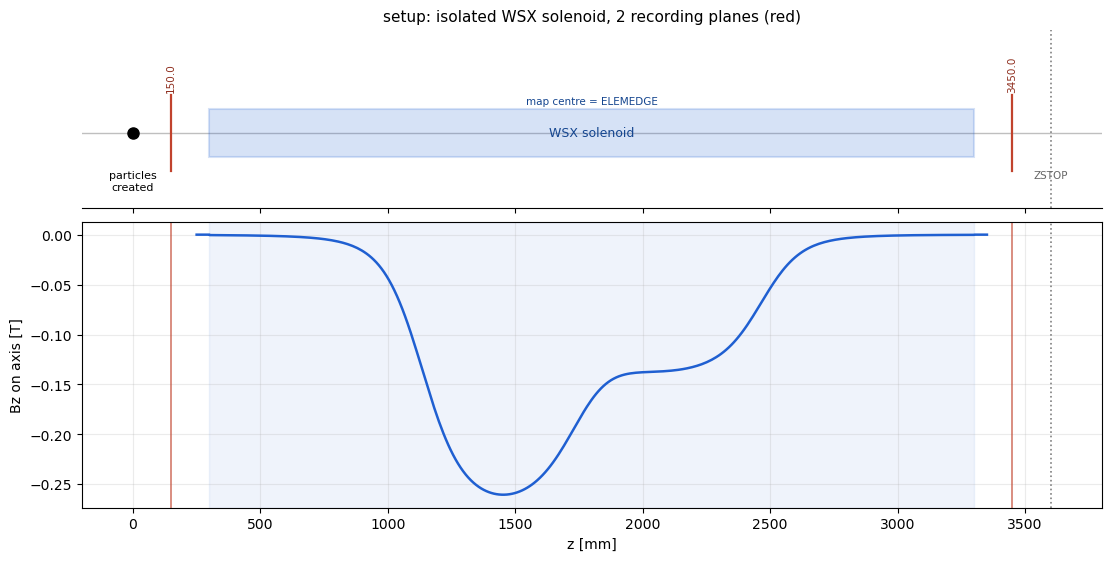

field      300 .. 3300 mm   (map centre 1800 mm)
planes     [150.0, 3450.0]
planes in field-free drift: [150.0, 3450.0]


In [66]:
# --- the setup being tested -------------------------------------------------
# Geometry is fixed by the two input files and is the same in both codes:
#   g4bl  `place MAG z=1800`, map local z -1500..+1500  -> field at 300..3300 mm
#   opalx `SOLENOID ELEMEDGE = 1.800`                   -> field at 0.300..3.300 m
# ELEMEDGE is the lab position of the map CENTRE, not of the field start.
MAP_CENTRE_MM = 1800
FIELD_MM      = (300, 3300)
ZSTOP_MM      = 3600
PLANES = PLANES_MM if "PLANES_MM" in dir() else [Z_IN_MM, Z_OUT_MM]

fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True,
                       gridspec_kw=dict(height_ratios=[1, 1.6]),
                       constrained_layout=True)

# ---- schematic ----
a = ax[0]
a.axhline(0, color="0.75", lw=1, zorder=0)
a.add_patch(plt.Rectangle((FIELD_MM[0], -0.35), FIELD_MM[1] - FIELD_MM[0], 0.7,
                          facecolor="#1f5fd1", alpha=0.18, edgecolor="#1f5fd1", lw=1.5))
a.text(np.mean(FIELD_MM), 0, "WSX solenoid",
       ha="center", va="center", fontsize=9, color="#14458f")
#a.plot([MAP_CENTRE_MM], [0], "v", ms=7, color="#14458f")
a.annotate("map centre = ELEMEDGE", (MAP_CENTRE_MM, 0.42), ha="center", fontsize=7.5,
           color="#14458f")

a.plot([0], [0], "o", ms=8, color="black", zorder=5)
a.annotate("particles\ncreated", (0, -0.55), ha="center", va="top", fontsize=8)
#a.annotate("", xy=(700, 0.75), xytext=(0, 0.75),
           #arrowprops=dict(arrowstyle="->", color="0.35"))
#a.text(350, 0.85, "beam", ha="center", fontsize=8, color="0.35")

for z in PLANES:
    a.plot([z, z], [-0.55, 0.55], "-", color="#c1432d", lw=1.6)
    a.annotate(f"{z}", (z, 0.62), ha="center", fontsize=7.5, rotation=90,
               color="#8f2f1f")
a.axvline(ZSTOP_MM, color="0.5", ls=":", lw=1.2)
a.annotate("ZSTOP", (ZSTOP_MM, -0.55), ha="center", va="top", fontsize=7.5, color="0.4")

a.set_ylim(-1.1, 1.5); a.set_yticks([])
a.set_title(f"setup: isolated WSX solenoid, {len(PLANES)} recording plane"
            f"{'s' if len(PLANES) > 1 else ''} (red)", fontsize=11)
for side in ("left", "right", "top"):
    a.spines[side].set_visible(False)

# ---- on-axis field, if g4bl has already been run ----
b = ax[1]
axis_file = Path("g4bl_axis.txt")
if axis_file.is_file():
    d = np.loadtxt(axis_file, comments="#", ndmin=2)
    b.plot(d[:, 2], d[:, 6], "-", color="#1f5fd1", lw=1.8)
    b.set_ylabel("Bz on axis [T]")
else:
    b.text(0.5, 0.5, "run g4bl to see the on-axis field here",
           transform=b.transAxes, ha="center", va="center", color="0.5", fontsize=9)
    b.set_yticks([])
b.axvspan(*FIELD_MM, color="#1f5fd1", alpha=0.07)
for z in PLANES:
    b.axvline(z, color="#c1432d", lw=1.2, alpha=0.7)
b.axvline(ZSTOP_MM, color="0.5", ls=":", lw=1.2)
b.grid(alpha=0.25)
b.set_xlabel("z [mm]")
b.set_xlim(-200, ZSTOP_MM + 200)
plt.show()

print(f"field      {FIELD_MM[0]} .. {FIELD_MM[1]} mm   (map centre {MAP_CENTRE_MM} mm)")
print(f"planes     {PLANES}")
print(f"planes in field-free drift: "
      f"{[z for z in PLANES if z < FIELD_MM[0] or z > FIELD_MM[1]]}")


## Write the particle files

The test set: a reference particle plus a ± step in each of the 6 phase-space
coordinates. One array, two encodings, so the codes cannot be fed different particles.

| rows | probes | why |
|---|---|---|
| 0 | reference | on-axis, at the design momentum |
| 1, 2 | ±x | the x column of the transfer map |
| 3, 4 | ±x′ | the x′ column |
| 5, 6 | ±y | the y column |
| 7, 8 | ±y′ | the y′ column |
| 9, 10 | ±z | the longitudinal column |
| 11, 12 | ±δ | the momentum column |

The ± pairs are what the centered finite differences later take, in exactly this order
(`PAIRS`). The set is **exactly symmetric in ±** on purpose: OPALX under `FROMFILE`
takes its reference orbit from the bunch *mean*, and symmetry is what makes that mean
coincide with G4BL's `reference particle=mu+ referenceMomentum=28`. Adding one
asymmetric particle would put a silent offset into every transverse comparison.

The two files hold the same 13 particles in different units:

- **`parts.txt`** — OPALX `FROMFILE`. Count, then a column-name line, then positions in
  **m** and momenta in **βγ** = \(p_i/(mc)\), so the reference is
  \(p_z = 0.028/0.10566 = 0.265\). The header is matched by *name*, not position.
- **`beam.txt`** — G4BL `BLTrackFile`. Three comment lines, then positions in **mm**,
  momenta in **MeV/c**, time in **ns**, then `PDGid` (−13 = mu+) and the bookkeeping
  columns. Column order here is fixed. `EventID = row + 1`, which is how particles are
  matched to OPALX `id` downstream.


In [67]:
def test_set():
    # 13 rows of (x, y, z [m], px, py, pz [beta*gamma]) plus a label per row saying
    # what it probes. Row 0 is the reference; the rest are +/- pairs in the order
    # the finite-difference transfer map expects (see PAIRS).
    rows, probes = [], []

    def row(probe, x=0.0, y=0.0, z=0.0, px=0.0, py=0.0, pz=BG0):
        rows.append((x, y, z, px, py, pz))
        probes.append(probe)

    mm, mrad = EPS["x"] * 1e3, EPS["xp"] * 1e3
    row("reference")
    row(f"x  +{mm:g} mm",             x=+EPS["x"])
    row(f"x  -{mm:g} mm",             x=-EPS["x"])
    row(f"x' +{mrad:g} mrad",         px=+EPS["xp"] * BG0)      # x' = px/pz
    row(f"x' -{mrad:g} mrad",         px=-EPS["xp"] * BG0)
    row(f"y  +{mm:g} mm",             y=+EPS["y"])
    row(f"y  -{mm:g} mm",             y=-EPS["y"])
    row(f"y' +{mrad:g} mrad",         py=+EPS["yp"] * BG0)
    row(f"y' -{mrad:g} mrad",         py=-EPS["yp"] * BG0)
    row(f"z  +{EPS['z'] * 1e3:g} mm", z=+EPS["z"])
    row(f"z  -{EPS['z'] * 1e3:g} mm", z=-EPS["z"])
    row(f"dp/p +{EPS['d']:g}",        pz=BG0 * (1 + EPS["d"]))
    row(f"dp/p -{EPS['d']:g}",        pz=BG0 * (1 - EPS["d"]))
    return np.array(rows), probes


P, PROBES = test_set()

# the symmetry that pins the OPALX reference orbit
mean_R, mean_P = P[:, :3].mean(axis=0), P[:, 3:].mean(axis=0)
assert np.allclose(mean_R, 0, atol=1e-15), mean_R
assert np.allclose(mean_P, [0, 0, BG0], atol=1e-15), mean_P

# --- parts.txt : OPALX FROMFILE  (m, beta*gamma) ------------------------------
with open("parts.txt", "w") as f:
    f.write(f"{len(P)}\n")
    f.write("x px y py z pz\n")
    for x, y, z, px, py, pz in P:
        f.write(" ".join(f"{v:.12e}" for v in (x, px, y, py, z, pz)) + "\n")

# --- beam.txt : G4BL BLTrackFile  (mm, MeV/c, ns) -----------------------------
# EventID = row + 1, so EventID == OPALX id + 1.
with open("beam.txt", "w") as f:
    f.write("#BLTrackFile g4bl_compare test set\n")
    f.write("#x y z Px Py Pz t PDGid EventID TrackID ParentID Weight\n")
    f.write("#mm mm mm MeV/c MeV/c MeV/c ns - - - - -\n")
    for i, (x, y, z, px, py, pz) in enumerate(P):
        f.write(
            f"{x*1e3:.9g} {y*1e3:.9g} {z*1e3:.9g} "
            f"{px*MU_MASS_MEV:.9g} {py*MU_MASS_MEV:.9g} {pz*MU_MASS_MEV:.9g} "
            f"0 -13 {i+1} 1 0 1\n"
        )


def show_table(title, note, headers, rows):
    w = [max(len(headers[k]), *(len(r[k]) for r in rows)) for k in range(len(headers))]
    print(title)
    for ln in note:
        print(f"    {ln}")
    print()
    print("  " + "  ".join(h.rjust(n) for h, n in zip(headers, w)))
    print("  " + "  ".join("-" * n for n in w))
    for r in rows:
        print("  " + "  ".join(v.rjust(n) for v, n in zip(r, w)))
    print()


print(f"mean R = {mean_R}   mean P = {mean_P}")
print("  (must be exactly 0,0,0 and 0,0,BG0 -- this is what pins the OPALX reference)\n")

show_table(
    "parts.txt  --  OPALX FROMFILE distribution",
    ["line 1: particle count.  line 2: column names, must contain x px y py z pz.",
     "then one row per particle: positions [m], momenta [beta*gamma] = p_i / (m c)."],
    ["row", "probes", "x [m]", "px [bg]", "y [m]", "py [bg]", "z [m]", "pz [bg]"],
    [[str(i), PROBES[i]] + [f"{v:.6e}" for v in (x, px, y, py, z, pz)]
     for i, (x, y, z, px, py, pz) in enumerate(P)],
)

show_table(
    "beam.txt  --  G4BL BLTrackFile beam input",
    ["3 comment lines, then one row per particle. PDGid -13 = mu+; TrackID/ParentID/",
     "Weight are 1/0/1 for primaries and are not shown. EventID = row + 1, which is",
     "how particles are matched to OPALX id downstream."],
    ["row", "probes", "x [mm]", "y [mm]", "z [mm]",
     "Px [MeV/c]", "Py [MeV/c]", "Pz [MeV/c]", "t [ns]", "EventID"],
    [[str(i), PROBES[i]]
     + [f"{v * 1e3:.6g}" for v in (x, y, z)]
     + [f"{v * MU_MASS_MEV:.6g}" for v in (px, py, pz)]
     + ["0", str(i + 1)]
     for i, (x, y, z, px, py, pz) in enumerate(P)],
)

print("Same particles, different units:")
print("  x[mm]    = 1000 * x[m]")
print(f"  P[MeV/c] = beta*gamma * m*c,   m*c = {MU_MASS_MEV:.7g} MeV/c")
print(f"Reference momentum: pz = {BG0:.7f} beta*gamma = {BG0 * MU_MASS_MEV:.6g} MeV/c")


mean R = [0. 0. 0.]   mean P = [0.         0.         0.26500502]
  (must be exactly 0,0,0 and 0,0,BG0 -- this is what pins the OPALX reference)

parts.txt  --  OPALX FROMFILE distribution
    line 1: particle count.  line 2: column names, must contain x px y py z pz.
    then one row per particle: positions [m], momenta [beta*gamma] = p_i / (m c).

  row       probes          x [m]        px [bg]          y [m]        py [bg]          z [m]       pz [bg]
  ---  -----------  -------------  -------------  -------------  -------------  -------------  ------------
    0    reference   0.000000e+00   0.000000e+00   0.000000e+00   0.000000e+00   0.000000e+00  2.650050e-01
    1     x  +1 mm   1.000000e-03   0.000000e+00   0.000000e+00   0.000000e+00   0.000000e+00  2.650050e-01
    2     x  -1 mm  -1.000000e-03   0.000000e+00   0.000000e+00   0.000000e+00   0.000000e+00  2.650050e-01
    3   x' +1 mrad   0.000000e+00   2.650050e-04   0.000000e+00   0.000000e+00   0.000000e+00  2.650050e-01


### Check the two files agree


In [68]:
# Read the two files back independently, convert beam.txt into OPALX units, and
# check they describe the same particles. This is a file-level check -- it does not
# depend on either code having run. (The stronger check is the entrance-plane
# comparison further down, which proves the codes actually ingested them.)
def read_parts(path="parts.txt"):
    # OPALX FROMFILE: count, then a column-NAME line -- FromFile::parseHeader maps
    # names to positions, so the column order is whatever the header says.
    ln = [l.strip() for l in open(path) if l.strip() and not l.startswith("#")]
    n_declared = int(ln[0])
    col = {name: i for i, name in enumerate(ln[1].split())}
    d = np.array([[float(v) for v in l.split()] for l in ln[2:]])
    return n_declared, col, np.column_stack([d[:, col[c]] for c in
                                             ("x", "y", "z", "px", "py", "pz")])


def read_beam(path="beam.txt"):
    # G4BL BLTrackFile: 3 comment lines, then a FIXED column order.
    b = np.loadtxt(path, comments="#", ndmin=2)
    return b[np.argsort(b[:, 8].astype(int))]        # sort by EventID


n_declared, col, parts = read_parts()
beam = read_beam()

# mm -> m, MeV/c -> beta*gamma
beam_as_opalx = np.column_stack([beam[:, 0] * 1e-3, beam[:, 1] * 1e-3, beam[:, 2] * 1e-3,
                                 beam[:, 3] / MU_MASS_MEV, beam[:, 4] / MU_MASS_MEV,
                                 beam[:, 5] / MU_MASS_MEV])
d = np.abs(beam_as_opalx - parts)

print(f"parts.txt declares {n_declared}, has {len(parts)} rows;  beam.txt has {len(beam)}")
print(f"parts.txt header maps to columns: {col}")
print(f"EventID == row + 1              : "
      f"{np.array_equal(beam[:, 8].astype(int), np.arange(1, len(beam) + 1))}")
print(f"beam.txt t == 0, PDGid == -13   : "
      f"{np.all(beam[:, 6] == 0)}, {np.all(beam[:, 7] == -13)}")
print("\nbeam.txt converted to OPALX units, minus parts.txt:")
for k, c in enumerate(("x", "y", "z", "px", "py", "pz")):
    unit = "m" if k < 3 else "beta*gamma"
    print(f"  max |diff| {c:>2}  {d[:, k].max():.3e} {unit}")
print("\n(Nonzero at 1e-14 or below is the 9-significant-digit write in beam.txt,")
print(" not a disagreement. Anything larger means the two files have drifted apart.)")


parts.txt declares 13, has 13 rows;  beam.txt has 13
parts.txt header maps to columns: {'x': 0, 'px': 1, 'y': 2, 'py': 3, 'z': 4, 'pz': 5}
EventID == row + 1              : True
beam.txt t == 0, PDGid == -13   : True, True

beam.txt converted to OPALX units, minus parts.txt:
  max |diff|  x  0.000e+00 m
  max |diff|  y  0.000e+00 m
  max |diff|  z  0.000e+00 m
  max |diff| px  1.469e-17 beta*gamma
  max |diff| py  1.469e-17 beta*gamma
  max |diff| pz  4.236e-14 beta*gamma

(Nonzero at 1e-14 or below is the 9-significant-digit write in beam.txt,
 not a disagreement. Anything larger means the two files have drifted apart.)



## Run both codes

```bash
cd opalx-runs/studies/g4bl_compare/wsx_solenoid

source /Users/rammann/Code/G4BL/G4beamline-3.08.app/Contents/root/bin/thisroot.sh
g4bl wsx_solenoid.g4bl > g4bl.log 2>&1

mpirun -n 1 <opalx> wsx_solenoid.in --info 1 > run.log 2>&1
```

One MPI rank only — particle-to-row identity across ranks isn't guaranteed. The cell
below runs both for you if the binaries are where they normally are.


In [69]:

from opalxruns import paths

G4BL_APP = paths.G4BL_APP


def run_g4bl():
    g4bl = G4BL_APP / "Contents/MacOS/g4bl"
    if not g4bl.is_file():
        raise FileNotFoundError(g4bl)
    for stale in ("Z150.txt", "Z3450.txt", "g4bl_axis.txt", "g4bl.log"):
        Path(stale).unlink(missing_ok=True)
    cmd = (f'source "{G4BL_APP}/Contents/root/bin/thisroot.sh" && '
           f'"{g4bl}" wsx_solenoid.g4bl')
    r = subprocess.run(["bash", "-c", cmd], capture_output=True, text=True)
    Path("g4bl.log").write_text(r.stdout + r.stderr)
    print("g4bl rc =", r.returncode, "-> g4bl.log")
    return r.returncode


def run_opalx():
    opalx = paths.opalx()                     # $OPALX
    for stale in ("MON_IN.h5", "MON_OUT.h5", "wsx_solenoid.h5", "wsx_solenoid.stat"):
        Path(stale).unlink(missing_ok=True)
    r = subprocess.run(["mpirun", "-n", "1", str(opalx), "wsx_solenoid.in", "--info", "1"],
                       capture_output=True, text=True)
    Path("run.log").write_text(r.stdout + r.stderr)
    print("opalx rc =", r.returncode, "->", opalx, "-> run.log")
    return r.returncode


run_g4bl()
run_opalx()


g4bl rc = 0 -> g4bl.log
opalx rc = 0 -> /Users/rammann/Code/OPALX/build/src/opalx -> run.log


0

## Readers


In [70]:
BLTRACK_COLS = ["x", "y", "z", "Px", "Py", "Pz", "t",
                "PDGid", "EventID", "TrackID", "ParentID", "Weight"]


def read_bltrack(path):
    # G4BL ASCII ntuple (#BLTrackFile). mm, MeV/c, ns. -> dict of arrays.
    data = np.loadtxt(path, comments="#", ndmin=2)
    return {name: data[:, i] for i, name in enumerate(BLTRACK_COLS[:data.shape[1]])}


def read_monitor(path):
    # OPALX MONITOR .h5, in m / beta*gamma / seconds. Particles arrive over
    # several tracking steps, so every Step#N group has to be concatenated.
    keys = ["id", "x", "y", "z", "px", "py", "pz", "time"]
    out = {k: [] for k in keys}
    with h5py.File(path, "r") as f:
        for g in sorted(f.keys(), key=lambda s: int(s.split("#")[1])):
            for k in keys:
                out[k].append(np.asarray(f[g][k]))
    out = {k: np.concatenate(v) for k, v in out.items()}
    o = np.argsort(out["id"])
    return {k: v[o] for k, v in out.items()}


def read_field_axis(path):
    # G4BL fieldntuple: x y z t Bx By Bz Ex Ey Ez, in mm / ns / tesla.
    # -> z [mm], and Bx, By, Bz [T].
    d = np.loadtxt(path, comments="#", ndmin=2)
    return d[:, 2], d[:, 4], d[:, 5], d[:, 6]



## Canonical coordinates

Both codes are reduced to the same 6-vector per particle, in the same row order as
`parts.txt`:

$$X = (x,\; x' = p_x/p_z,\; y,\; y',\; \zeta = -\beta_0 c\,(t - t_0),\; \delta = |p|/p_0 - 1)$$

with lengths in **m** and angles in **rad**. \(t_0\) is the arrival time of particle 0
(the on-axis reference) at that same plane — the one quantity both codes give directly.

`x'` and `y'` are the primary comparison: they're ratios of momenta, so they don't care
about either code's frame convention.


In [71]:

def canon_g4bl(d):
    n = len(d["x"])
    idx = np.argsort(d["EventID"])
    x  = d["x"][idx] * 1e-3
    y  = d["y"][idx] * 1e-3
    px = d["Px"][idx] / MU_MASS_MEV
    py = d["Py"][idx] / MU_MASS_MEV
    pz = d["Pz"][idx] / MU_MASS_MEV
    t  = d["t"][idx]                                   # ns
    zeta  = -BETA0 * C_MM_PER_NS * (t - t[0]) * 1e-3   # mm -> m
    delta = np.sqrt(px**2 + py**2 + pz**2) / BG0 - 1.0
    return np.vstack([x, px / pz, y, py / pz, zeta, delta]), d["EventID"][idx].astype(int)


def canon_opalx(d):
    px, py, pz = d["px"], d["py"], d["pz"]
    t = d["time"] * 1e9                                # s -> ns
    zeta  = -BETA0 * C_MM_PER_NS * (t - t[0]) * 1e-3
    delta = np.sqrt(px**2 + py**2 + pz**2) / BG0 - 1.0
    return np.vstack([d["x"], px / pz, d["y"], py / pz, zeta, delta]), d["id"].astype(int)


g_in,  g_out  = read_bltrack("Z150.txt"),  read_bltrack("Z3450.txt")
o_in,  o_out  = read_monitor("MON_IN.h5"), read_monitor("MON_OUT.h5")

Xg_in, id_g_in  = canon_g4bl(g_in)
Xg_out, id_g_out = canon_g4bl(g_out)
Xo_in, id_o_in  = canon_opalx(o_in)
Xo_out, id_o_out = canon_opalx(o_out)

# --- sanity: nothing lost, and the two codes are talking about the same particles
print(f"G4BL   Z150 {Xg_in.shape[1]:3d}   Z3450 {Xg_out.shape[1]:3d}")
print(f"OPALX  MON_IN {Xo_in.shape[1]:3d}   MON_OUT {Xo_out.shape[1]:3d}")
for nm, ids, expect in [("g4bl in", id_g_in, np.arange(1, 14)),
                        ("g4bl out", id_g_out, np.arange(1, 14)),
                        ("opalx in", id_o_in, np.arange(0, 13)),
                        ("opalx out", id_o_out, np.arange(0, 13))]:
    ok = len(ids) == len(expect) and np.array_equal(ids, expect)
    print(f"  {nm:10s} ids {'OK' if ok else 'MISMATCH: ' + str(ids)}")
print("\n(G4BL EventID == OPALX id + 1 by construction)")


G4BL   Z150  13   Z3450  13
OPALX  MON_IN  13   MON_OUT  13
  g4bl in    ids OK
  g4bl out   ids OK
  opalx in   ids OK
  opalx out  ids OK

(G4BL EventID == OPALX id + 1 by construction)


## Per-particle comparison at the exit plane


In [72]:

def diff_table(Xg, Xo, title):
    D = Xo - Xg
    print(title)
    print(f"{'#':>3} {'coord':>6} "
          f"{'G4BL':>14} {'OPALX':>14} {'diff':>12}")
    print("-" * 66)
    for j in range(Xg.shape[1]):
        for i, lab in enumerate(LABELS):
            print(f"{j:>3} {lab:>6} {Xg[i, j]:>14.6e} {Xo[i, j]:>14.6e} {D[i, j]:>12.3e}")
        print()
    print("max |diff| per coordinate:")
    for i, lab in enumerate(LABELS):
        unit = "m" if lab in ("x", "y", "zeta") else ("rad" if "'" in lab else "-")
        print(f"  {lab:>6} {np.abs(D[i]).max():.3e} {unit}")
    return D


D_out = diff_table(Xg_out, Xo_out, "exit plane z = 3450 mm  (OPALX - G4BL)")


exit plane z = 3450 mm  (OPALX - G4BL)
  #  coord           G4BL          OPALX         diff
------------------------------------------------------------------
  0      x  -4.055260e-16   0.000000e+00    4.055e-16
  0     x'  -2.367564e-16   0.000000e+00    2.368e-16
  0      y   1.663710e-16   0.000000e+00   -1.664e-16
  0     y'   4.398857e-17   0.000000e+00   -4.399e-17
  0   zeta  -0.000000e+00  -0.000000e+00    0.000e+00
  0  delta  -2.220446e-16  -5.551115e-14   -5.529e-14

  1      x  -1.858000e-04  -1.858018e-04   -1.831e-09
  1     x'  -1.904329e-04  -1.904345e-04   -1.613e-09
  1      y  -1.007140e-03  -1.007133e-03    7.024e-09
  1     y'  -1.024343e-03  -1.024343e-03   -1.310e-10
  1   zeta  -0.000000e+00  -1.422475e-06   -1.422e-06
  1  delta   5.427713e-07  -5.673240e-14   -5.428e-07

  2      x   1.858000e-04   1.858018e-04    1.831e-09
  2     x'   1.904329e-04   1.904345e-04    1.613e-09
  2      y   1.007140e-03   1.007133e-03   -7.024e-09
  2     y'   1.024343e-03   

In [73]:

# The same at the entrance plane -- this one is pure plumbing: both codes should
# reproduce the input file, so a nonzero difference here means the two codes were
# not fed the same particles.
print("entrance plane z = 150 mm  (OPALX - G4BL), max |diff| per coordinate:")
D_in = Xo_in - Xg_in
for i, lab in enumerate(LABELS):
    print(f"  {lab:>6} {np.abs(D_in[i]).max():.3e}")
print("\nG4BL ASCII output is %.6g -- 6 significant digits -- so ~5e-7 relative is")
print("the floor for every number here.")


entrance plane z = 150 mm  (OPALX - G4BL), max |diff| per coordinate:
       x 1.409e-18
      x' 0.000e+00
       y 1.409e-18
      y' 0.000e+00
    zeta 6.475e-07
   delta 1.599e-13

G4BL ASCII output is %.6g -- 6 significant digits -- so ~5e-7 relative is
the floor for every number here.



## Transfer matrices

6×6 map from the 150 mm plane to the 3450 mm plane, by centered finite differences
over the ± pairs. Measured the same way from each code, so they're directly comparable.


In [74]:

def transfer_map(Xin, Xout):
    din  = np.column_stack([(Xin[:, p] - Xin[:, m]) / 2.0 for p, m in PAIRS])
    dout = np.column_stack([(Xout[:, p] - Xout[:, m]) / 2.0 for p, m in PAIRS])
    return dout @ np.linalg.inv(din)


Mg = transfer_map(Xg_in, Xg_out)
Mo = transfer_map(Xo_in, Xo_out)


def print_two(A, B, na, nb):
    print(f"{'':>6}" + "".join(f"{l:>12}" for l in LABELS) + "     |" +
          "".join(f"{l:>12}" for l in LABELS))
    print(f"{'':>6}{na:>72}     |{nb:>72}")
    for i in range(6):
        ra = "".join(f"{A[i, j]:>12.5f}" for j in range(6))
        rb = "".join(f"{B[i, j]:>12.5f}" for j in range(6))
        print(f"{LABELS[i]:>6}{ra}     |{rb}")


print_two(Mg, Mo, "G4BL", "OPALX")
print()
Md = Mo - Mg
print("OPALX - G4BL, element-wise:")
for i in range(6):
    print(f"{LABELS[i]:>6}" + "".join(f"{Md[i, j]:>12.2e}" for j in range(6)))
print(f"\nmax |element difference| = {np.abs(Md).max():.3e}")

J = np.zeros((6, 6))
for k in range(3):
    J[2 * k, 2 * k + 1], J[2 * k + 1, 2 * k] = 1.0, -1.0
for nm, M in (("G4BL", Mg), ("OPALX", Mo)):
    print(f"{nm:6s} symplectic residual max|M^T J M - J| = "
          f"{np.abs(M.T @ J @ M - J).max():.3e}")
print("\n(zeta and delta as defined here are conjugate only up to a factor, and the")
print(" finite-difference steps are 1e-3, so a residual of order 1e-3 is the method,")
print(" not the code. Compare the two codes' residuals to each other, not to zero.)")


                 x          x'           y          y'        zeta       delta     |           x          x'           y          y'        zeta       delta
                                                                          G4BL     |                                                                   OPALX
     x    -0.18580     0.06972     1.00714    -0.37444     0.00000     0.00000     |    -0.18580     0.06972     1.00713    -0.37444     0.00000     0.00000
    x'    -0.19043    -0.10812     1.02434     0.57894     0.00000     0.00000     |    -0.19043    -0.10812     1.02434     0.57894     0.00000     0.00000
     y    -1.00714     0.37444    -0.18580     0.06972     0.00000     0.00000     |    -1.00713     0.37444    -0.18580     0.06972     0.00000     0.00000
    y'    -1.02434    -0.57894    -0.19043    -0.10812     0.00000     0.00000     |    -1.02434    -0.57894    -0.19043    -0.10812     0.00000     0.00000
  zeta     0.00000     0.00000     0.00000     0.00000    

### Plotted

Same three matrices as above. The colour scale is shared between G4BL and OPALX so
they can be read against each other; the difference panel has its own, much smaller
scale. Values are printed in each cell — the map is only 36 numbers, and reading them
off the picture beats hunting through the table.


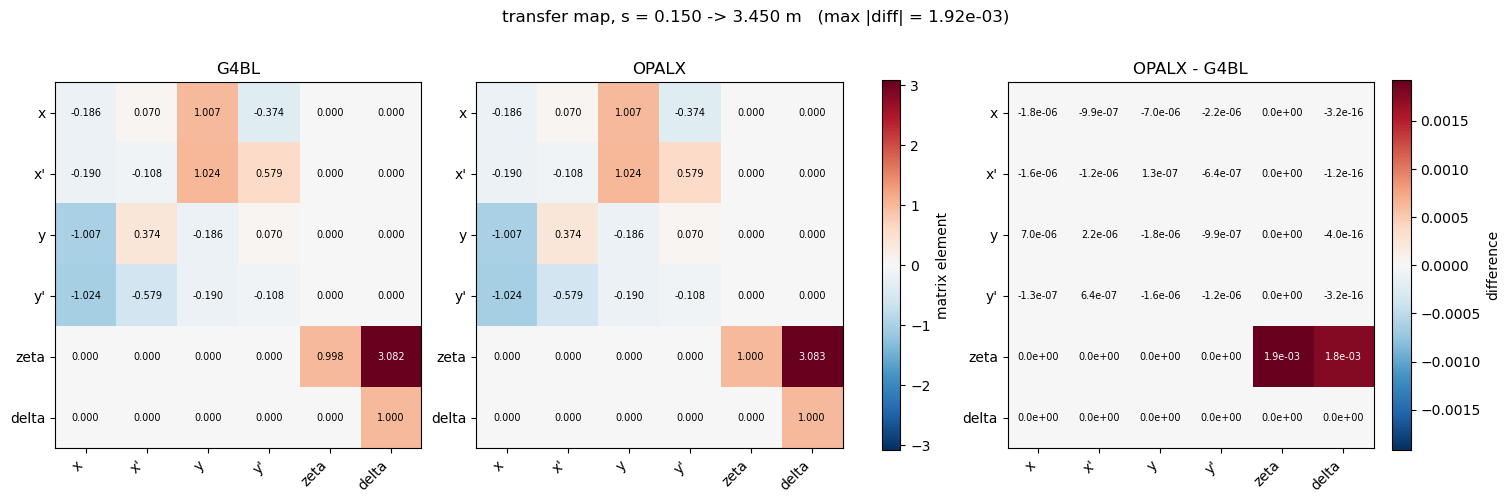

In [75]:
def plot_matrix(ax, M, title, vmax=None, fmt="{:.3f}"):
    v = vmax if vmax is not None else np.abs(M).max()
    im = ax.imshow(M, cmap="RdBu_r", vmin=-v, vmax=v)
    ax.set_xticks(range(6), LABELS, rotation=45, ha="right")
    ax.set_yticks(range(6), LABELS)
    ax.set_title(title)
    for r in range(6):
        for c in range(6):
            val = M[r, c]
            # white text on the saturated ends, black in the pale middle
            colour = "white" if abs(val) > 0.6 * v else "black"
            ax.text(c, r, fmt.format(val), ha="center", va="center",
                    fontsize=7, color=colour)
    return im


fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

vshared = max(np.abs(Mg).max(), np.abs(Mo).max())
im0 = plot_matrix(ax[0], Mg, "G4BL", vmax=vshared)
im1 = plot_matrix(ax[1], Mo, "OPALX", vmax=vshared)
fig.colorbar(im1, ax=ax[:2], shrink=0.8, label="matrix element")

im2 = plot_matrix(ax[2], Md, "OPALX - G4BL", fmt="{:.1e}")
fig.colorbar(im2, ax=ax[2], shrink=0.8, label="difference")

fig.suptitle(f"transfer map, s = {Z_IN_MM/1e3:.3f} -> {Z_OUT_MM/1e3:.3f} m"
             f"   (max |diff| = {np.abs(Md).max():.2e})")
plt.show()


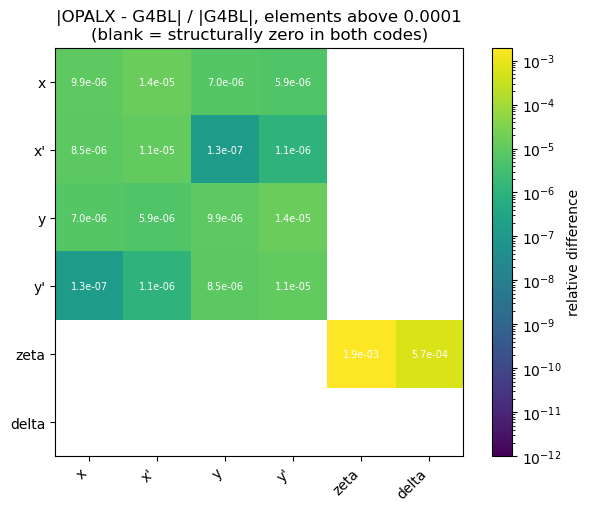

worst relative difference among elements > 0.0001: 1.92e-03


In [76]:
# The difference panel above is dominated by whichever element is largest. This is
# the same information per element, relative to the element's own size, so a small
# element that is badly wrong is not hidden by a large element that is slightly off.
floor = 1e-4                       # elements below this are treated as structurally zero
denom = np.maximum(np.abs(Mg), floor)
rel = np.abs(Md) / denom
big = np.abs(Mg) > floor

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
masked = np.where(big, rel, np.nan)
im = ax.imshow(masked, cmap="viridis",
               norm=plt.matplotlib.colors.LogNorm(
                   vmin=max(np.nanmin(masked), 1e-12), vmax=max(np.nanmax(masked), 1e-11)))
ax.set_xticks(range(6), LABELS, rotation=45, ha="right")
ax.set_yticks(range(6), LABELS)
ax.set_title(f"|OPALX - G4BL| / |G4BL|, elements above {floor:g}\n"
             "(blank = structurally zero in both codes)")
for r in range(6):
    for c in range(6):
        if big[r, c]:
            ax.text(c, r, f"{rel[r, c]:.1e}", ha="center", va="center",
                    fontsize=7, color="white")
fig.colorbar(im, ax=ax, label="relative difference")
plt.show()

print(f"worst relative difference among elements > {floor:g}: "
      f"{np.nanmax(np.where(big, rel, np.nan)):.2e}")



## Larmor rotation

A solenoid's 4×4 block is a rotation by $\theta_L$ applied to a common 2×2:

$$M_{4\times4} = \begin{pmatrix} \cos\theta_L\,M_2 & \sin\theta_L\,M_2 \\ -\sin\theta_L\,M_2 & \cos\theta_L\,M_2\end{pmatrix},
\qquad \theta_L = \frac{\int B_z\,ds}{2B\rho}$$

**The sign matters.** `place MAG z=1800 rotation=Y180` is a 180° rotation about y,
$R = \mathrm{diag}(-1, 1, -1)$, so it mirrors the map in z *and* flips the sign of $B_z$:
$B_z^{\text{lab}}(z) = -B_z^{\text{map}}(z_{\text{place}} - z)$, with $B_r$ unchanged. The
map is strongly asymmetric in z, so this is the sharpest check that both codes agree on
what the placement means.


In [77]:
def larmor_from_matrix(M):
    # M[0:2,0:2] = cos(th)*A and M[2:4,0:2] = -sin(th)*A for a common 2x2 A, so
    # atan2 gives th only modulo pi -- the two branches differ by A -> -A. The
    # branch is fixed by requiring A[0,1] > 0, i.e. a net-drifting channel.
    # (That holds while the Larmor phase advance is below pi, which it is here;
    # a much stronger solenoid would need a different discriminant.)
    Mxx, Myx = M[0:2, 0:2], M[2:4, 0:2]
    th0 = np.arctan2(-M[2, 0], M[0, 0])
    for th in (th0, th0 - np.copysign(np.pi, th0)):
        A = np.cos(th) * Mxx - np.sin(th) * Myx
        if A[0, 1] > 0:
            return th
    return th0


z_ax, bx_ax, by_ax, bz_ax = read_field_axis("g4bl_axis.txt")
int_bz = np.trapezoid(bz_ax, z_ax * 1e-3) if hasattr(np, "trapezoid") \
         else np.trapz(bz_ax, z_ax * 1e-3)
theta_field = int_bz / (2 * BRHO)

# matrix-free cross-check: the x+ particle, rotated about the axis
theta_traj_g = np.arctan2(Xg_out[2, 1], Xg_out[0, 1])
theta_traj_o = np.arctan2(Xo_out[2, 1], Xo_out[0, 1])

print(f"peak |Bz| on axis        {np.abs(bz_ax).max():.6f} T "
      f"at z = {z_ax[np.abs(bz_ax).argmax()]:.0f} mm")
print(f"int Bz dz                {int_bz:+.6f} T*m")
print()
print(f"theta from field         {theta_field:+.6f} rad  ({np.degrees(theta_field):+.3f} deg)")
print(f"theta from G4BL  matrix  {larmor_from_matrix(Mg):+.6f} rad")
print(f"theta from OPALX matrix  {larmor_from_matrix(Mo):+.6f} rad")
print(f"theta from G4BL  x+ traj {theta_traj_g:+.6f} rad   (+-pi ambiguous: the x+")
print(f"theta from OPALX x+ traj {theta_traj_o:+.6f} rad    particle crosses the axis)")
print()
print(f"OPALX - G4BL (matrix)    {larmor_from_matrix(Mo) - larmor_from_matrix(Mg):+.3e} rad")


peak |Bz| on axis        0.260443 T at z = 1450 mm
int Bz dz                -0.259104 T*m

theta from field         -1.387094 rad  (-79.475 deg)
theta from G4BL  matrix  -1.388365 rad
theta from OPALX matrix  -1.388362 rad
theta from G4BL  x+ traj -1.753228 rad   (+-pi ambiguous: the x+
theta from OPALX x+ traj -1.753231 rad    particle crosses the axis)

OPALX - G4BL (matrix)    +3.002e-06 rad


## Field import check

OPALX's `Bx_ref, By_ref, Bz_ref` from the `.stat` file are the field on the reference
particle, which sits on the axis here — so they're directly comparable to G4BL's
on-axis `fieldntuple` dump. **No tracking physics is involved in this comparison**, so
a mismatch here is a field-map plumbing problem, not a physics disagreement, and
everything below it is meaningless until it passes.

`Bx` and `By` vanish on the axis of an axisymmetric magnet, so those two are an
alignment check rather than a field check.


In [78]:
meta, st = parse_opal_stat("wsx_solenoid.stat")
s_opalx = st["s"].to_numpy()
B_opalx = {c: st[f"B{c}_ref"].to_numpy() for c in ("x", "y", "z")}
B_g4bl  = {"x": bx_ax, "y": by_ax, "z": bz_ax}

# g4bl z [mm] / 1000 == opalx s [m], by construction
Bpeak = np.abs(bz_ax).max()
rows = []
for c in ("x", "y", "z"):
    at_s = np.interp(s_opalx, z_ax * 1e-3, B_g4bl[c], left=np.nan, right=np.nan)
    ok = np.isfinite(at_s)
    d = B_opalx[c][ok] - at_s[ok]
    rows.append((c, np.abs(B_opalx[c]).max(), np.abs(B_g4bl[c]).max(),
                 np.abs(d).max(), np.abs(d).max() / Bpeak))

print(f"samples compared  {ok.sum()}      (Bz peak = {Bpeak:.6f} T)\n")
print(f"{'comp':>4} {'peak |B| OPALX':>16} {'peak |B| G4BL':>16} "
      f"{'max |diff|':>12} {'/ Bz peak':>12}")
print("-" * 66)
for c, po, pg, md_, rel_ in rows:
    print(f"{'B' + c:>4} {po:>16.3e} {pg:>16.3e} {md_:>12.3e} {rel_:>12.2e}")

print("\nBx and By are zero on the axis of an axisymmetric magnet, so those two rows")
print("are an alignment check: a nonzero value means the reference orbit is not on")
print("the magnet axis, or the map is not axisymmetric about it.")

iz = np.abs(bz_opalx_peak := B_opalx["z"]).argmax()
print(f"\npeak Bz OPALX  {bz_opalx_peak[iz]:+.6f} T at s = {s_opalx[iz]:.4f} m")
jz = np.abs(bz_ax).argmax()
print(f"peak Bz G4BL   {bz_ax[jz]:+.6f} T at z = {z_ax[jz] * 1e-3:.4f} m")

_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
print(f"int Bz ds OPALX {_trapz(B_opalx['z'], s_opalx):+.6f} T*m")
print(f"int Bz dz G4BL  {_trapz(bz_ax, z_ax * 1e-3):+.6f} T*m")

bz_opalx = B_opalx["z"]        # kept for the plots below


samples compared  4037      (Bz peak = 0.260443 T)

comp   peak |B| OPALX    peak |B| G4BL   max |diff|    / Bz peak
------------------------------------------------------------------
  Bx        0.000e+00        3.190e-17    3.189e-17     1.22e-16
  By        0.000e+00        0.000e+00    0.000e+00     0.00e+00
  Bz        2.604e-01        2.604e-01    3.058e-04     1.17e-03

Bx and By are zero on the axis of an axisymmetric magnet, so those two rows
are an alignment check: a nonzero value means the reference orbit is not on
the magnet axis, or the map is not axisymmetric about it.

peak Bz OPALX  -0.260442 T at s = 1.4499 m
peak Bz G4BL   -0.260443 T at z = 1.4500 m
int Bz ds OPALX -0.259104 T*m
int Bz dz G4BL  -0.259104 T*m


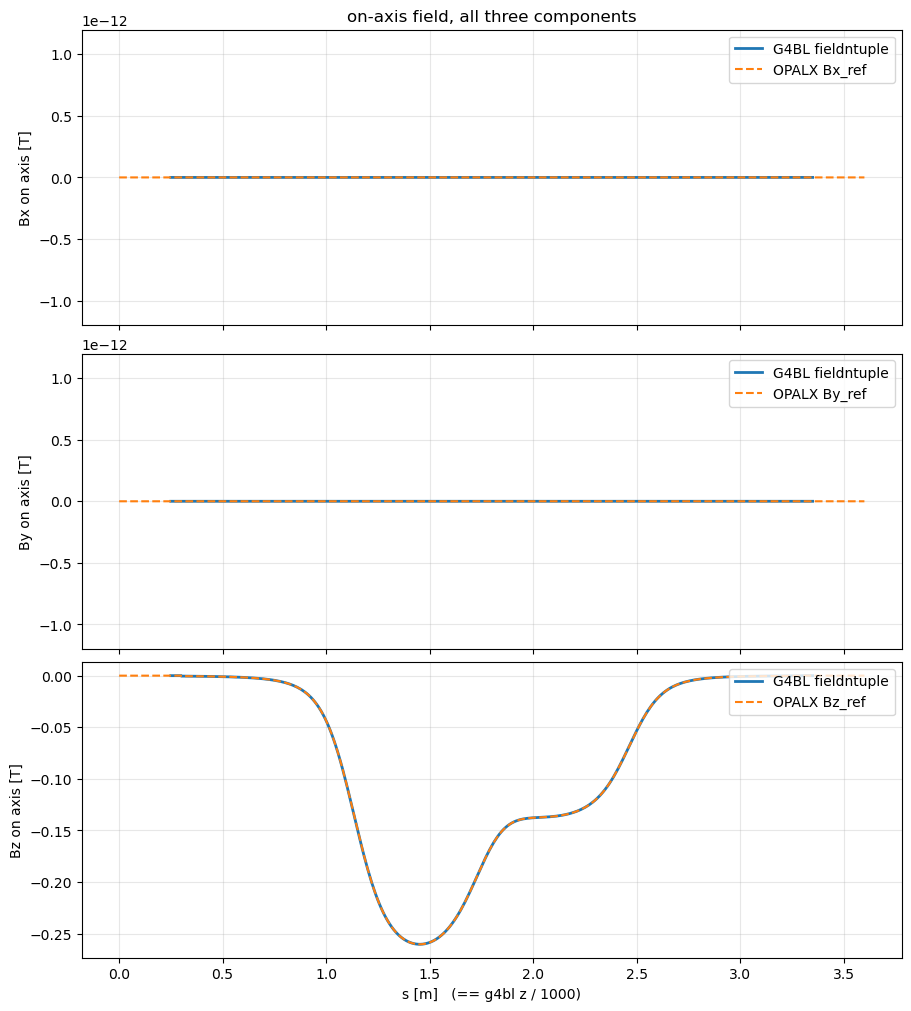

In [82]:
fig, ax = plt.subplots(3, 1, figsize=(9, 10), sharex=True, constrained_layout=True)

for k, c in enumerate(("x", "y", "z")):
    ax[k].plot(z_ax * 1e-3, B_g4bl[c], label="G4BL fieldntuple", lw=2)
    ax[k].plot(s_opalx, B_opalx[c], "--", label=f"OPALX B{c}_ref", lw=1.5)
    ax[k].set_ylabel(f"B{c} on axis [T]")
    ax[k].grid(alpha=.3)
    ax[k].legend(loc="upper right")
ax[0].set_title("on-axis field, all three components")
ax[2].set_xlabel("s [m]   (== g4bl z / 1000)")

# Bx and By are ~0, so let them share a tight symmetric scale rather than
# autoscaling on numerical dust and looking like structure.
tiny = max(np.abs(B_g4bl["x"]).max(), np.abs(B_g4bl["y"]).max(),
           np.abs(B_opalx["x"]).max(), np.abs(B_opalx["y"]).max(), 1e-12)
for k in (0, 1):
    ax[k].set_ylim(-1.2 * tiny, 1.2 * tiny)
plt.show()


## Plots


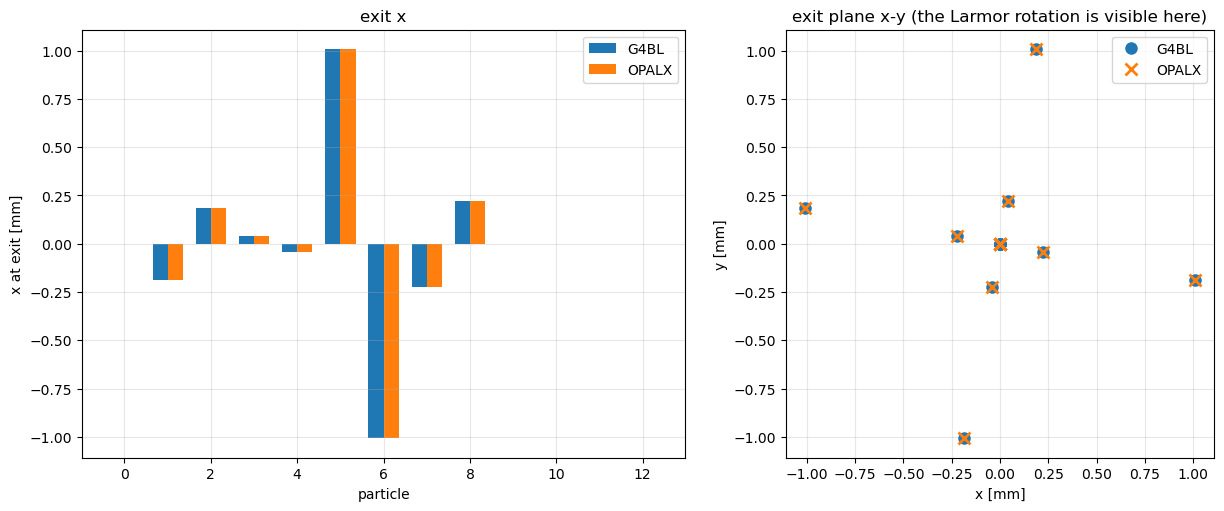

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

w = 0.35
j = np.arange(Xg_out.shape[1])
ax[0].bar(j - w/2, Xg_out[0] * 1e3, w, label="G4BL")
ax[0].bar(j + w/2, Xo_out[0] * 1e3, w, label="OPALX")
ax[0].set_xlabel("particle"); ax[0].set_ylabel("x at exit [mm]")
ax[0].set_title("exit x"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(Xg_out[0] * 1e3, Xg_out[2] * 1e3, "o", ms=8, label="G4BL")
ax[1].plot(Xo_out[0] * 1e3, Xo_out[2] * 1e3, "x", ms=8, mew=2, label="OPALX")
ax[1].set_xlabel("x [mm]"); ax[1].set_ylabel("y [mm]")
ax[1].set_title("exit plane x-y (the Larmor rotation is visible here)")
ax[1].set_aspect("equal"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.show()
